<a href="https://colab.research.google.com/github/PranjaliS1811/Customer_purchase_repo/blob/main/covid19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("imdevskp/corona-virus-report")

print("Dataset path:", path)

# Show files
print(os.listdir(path))

# Read CSV file
df = pd.read_csv(path + "/country_wise_latest.csv")

# Show first 5 rows
print(df.head())



100%|██████████| 19.0M/19.0M [00:02<00:00, 8.97MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/imdevskp/corona-virus-report/versions/166
['usa_county_wise.csv', 'full_grouped.csv', 'covid_19_clean_complete.csv', 'country_wise_latest.csv', 'worldometer_data.csv', 'day_wise.csv']
  Country/Region  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   
2        Algeria      27973    1163      18837    7973        616           8   
3        Andorra        907      52        803      52         10           0   
4         Angola        950      41        242     667         18           1   

   New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   
2            749                4.16                  67.34   
3              0               

In [ ]:
print(df.describe())

          Confirmed         Deaths     Recovered        Active     New cases  \
count  1.870000e+02     187.000000  1.870000e+02  1.870000e+02    187.000000   
mean   8.813094e+04    3497.518717  5.063148e+04  3.400194e+04   1222.957219   
std    3.833187e+05   14100.002482  1.901882e+05  2.133262e+05   5710.374790   
min    1.000000e+01       0.000000  0.000000e+00  0.000000e+00      0.000000   
25%    1.114000e+03      18.500000  6.265000e+02  1.415000e+02      4.000000   
50%    5.059000e+03     108.000000  2.815000e+03  1.600000e+03     49.000000   
75%    4.046050e+04     734.000000  2.260600e+04  9.149000e+03    419.500000   
max    4.290259e+06  148011.000000  1.846641e+06  2.816444e+06  56336.000000   

        New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
count   187.000000     187.000000          187.000000             187.000000   
mean     28.957219     933.812834            3.019519              64.820535   
std     120.037173    4197.719635      

In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [ ]:
print(df.columns)

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')


In [ ]:
print(df.isnull().sum())

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64


In [ ]:
df['Confirmed'] = df['Confirmed'].fillna(0)
print(df.drop_duplicates)

<bound method DataFrame.drop_duplicates of          Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
0           Afghanistan      36263    1269      25198    9796        106   
1               Albania       4880     144       2745    1991        117   
2               Algeria      27973    1163      18837    7973        616   
3               Andorra        907      52        803      52         10   
4                Angola        950      41        242     667         18   
..                  ...        ...     ...        ...     ...        ...   
182  West Bank and Gaza      10621      78       3752    6791        152   
183      Western Sahara         10       1          8       1          0   
184               Yemen       1691     483        833     375         10   
185              Zambia       4552     140       2815    1597         71   
186            Zimbabwe       2704      36        542    2126        192   

     New deaths  New recovered  Deaths / 100

In [ ]:
Q1 = df['Confirmed'].quantile(0.25)
Q3 = df['Confirmed'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Confirmed'] >= Q1 - 1.5*IQR) & (df['Confirmed'] <= Q3 + 1.5*IQR)]
print(df.head())

         Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
1               Albania       4880     144       2745    1991        117   
3               Andorra        907      52        803      52         10   
4                Angola        950      41        242     667         18   
5   Antigua and Barbuda         86       3         65      18          4   
11              Bahamas        382      11         91     280         40   

    New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
1            6             63                2.95                  56.25   
3            0              0                5.73                  88.53   
4            1              0                4.32                  25.47   
5            0              5                3.49                  75.58   
11           0              0                2.88                  23.82   

    Deaths / 100 Recovered  Confirmed last week  1 week change  \
1                   

In [ ]:
cols = ['Confirmed', 'Deaths', 'Recovered', 'Active']

df[cols] = df[cols].apply(lambda x: x.clip(lower=0))
print(df.head())

         Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
1               Albania       4880     144       2745    1991        117   
3               Andorra        907      52        803      52         10   
4                Angola        950      41        242     667         18   
5   Antigua and Barbuda         86       3         65      18          4   
11              Bahamas        382      11         91     280         40   

    New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
1            6             63                2.95                  56.25   
3            0              0                5.73                  88.53   
4            1              0                4.32                  25.47   
5            0              5                3.49                  75.58   
11           0              0                2.88                  23.82   

    Deaths / 100 Recovered  Confirmed last week  1 week change  \
1                   

/tmp/ipykernel_5259/3939621636.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cols] = df[cols].apply(lambda x: x.clip(lower=0))


In [ ]:
df.sort_values('Confirmed', ascending=False).head(10)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
46,Czechia,15516,373,11428,3715,192,2,0,2.40,73.65,3.26,14098,1418,10.06,Europe
8,Australia,15303,167,9311,5825,368,6,137,1.09,60.84,1.79,12428,2875,23.13,Western Pacific
53,El Salvador,15035,408,7778,6849,405,8,130,2.71,51.73,5.25,12207,2828,23.17,Americas
58,Ethiopia,14547,228,6386,7933,579,5,170,1.57,43.90,3.57,10207,4340,42.52,Africa
155,South Korea,14203,300,13007,896,28,1,102,2.11,91.58,2.31,13816,387,2.80,Western Pacific
47,Denmark,13761,613,12605,543,109,0,77,4.45,91.60,4.86,13453,308,2.29,Europe
159,Sudan,11424,720,5939,4765,39,3,49,6.30,51.99,12.12,10992,432,3.93,Eastern Mediterranean
182,West Bank and Gaza,10621,78,3752,6791,152,2,0,0.73,35.33,2.08,8916,1705,19.12,Eastern Mediterranean
25,Bulgaria,10621,347,5585,4689,194,7,230,3.27,52.58,6.21,8929,1692,18.95,Europe
21,Bosnia and Herzegovina,10498,294,4930,5274,731,14,375,2.80,46.96,5.96,8479,2019,23.81,Europe


In [ ]:
df.sort_values('Deaths', ascending=False).head(10)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
159,Sudan,11424,720,5939,4765,39,3,49,6.30,51.99,12.12,10992,432,3.93,Eastern Mediterranean
47,Denmark,13761,613,12605,543,109,0,77,4.45,91.60,4.86,13453,308,2.29,Europe
77,Hungary,4448,596,3329,523,13,0,0,13.40,74.84,17.90,4339,109,2.51,Europe
184,Yemen,1691,483,833,375,10,4,36,28.56,49.26,57.98,1619,72,4.45,Eastern Mediterranean
125,North Macedonia,10213,466,5564,4183,127,6,137,4.56,54.48,8.38,9249,964,10.42,Europe
53,El Salvador,15035,408,7778,6849,405,8,130,2.71,51.73,5.25,12207,2828,23.17,Americas
46,Czechia,15516,373,11428,3715,192,2,0,2.40,73.65,3.26,14098,1418,10.06,Europe
25,Bulgaria,10621,347,5585,4689,194,7,230,3.27,52.58,6.21,8929,1692,18.95,Europe
60,Finland,7398,329,6920,149,5,0,0,4.45,93.54,4.75,7340,58,0.79,Europe
155,South Korea,14203,300,13007,896,28,1,102,2.11,91.58,2.31,13816,387,2.80,Western Pacific


In [ ]:
df['Death_rate'] = (df['Deaths'] / df['Confirmed']) * 100
print(df.head(10))

         Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
1               Albania       4880     144       2745    1991        117   
3               Andorra        907      52        803      52         10   
4                Angola        950      41        242     667         18   
5   Antigua and Barbuda         86       3         65      18          4   
8             Australia      15303     167       9311    5825        368   
11              Bahamas        382      11         91     280         40   
14             Barbados        110       7         94       9          0   
17               Belize         48       2         26      20          0   
18                Benin       1770      35       1036     699          0   
19               Bhutan         99       0         86      13          4   

    New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
1            6             63                2.95                  56.25   
3          

In [ ]:
df['Recovery_rate'] = (df['Recovered'] / df['Confirmed']) * 100
print(df.head(10))

            Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
1                  Albania       4880     144       2745    1991        117   
3                  Andorra        907      52        803      52         10   
4                   Angola        950      41        242     667         18   
5      Antigua and Barbuda         86       3         65      18          4   
11                 Bahamas        382      11         91     280         40   
14                Barbados        110       7         94       9          0   
17                  Belize         48       2         26      20          0   
18                   Benin       1770      35       1036     699          0   
19                  Bhutan         99       0         86      13          4   
21  Bosnia and Herzegovina      10498     294       4930    5274        731   

    New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
1            6             63                2.95     

/tmp/ipykernel_5259/3161806225.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Recovery_rate'] = (df['Recovered'] / df['Confirmed']) * 100


In [ ]:
region_data = df.groupby('WHO Region')['Confirmed'].sum().sort_values()
print(df.head(10))

            Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
1                  Albania       4880     144       2745    1991        117   
3                  Andorra        907      52        803      52         10   
4                   Angola        950      41        242     667         18   
5      Antigua and Barbuda         86       3         65      18          4   
11                 Bahamas        382      11         91     280         40   
14                Barbados        110       7         94       9          0   
17                  Belize         48       2         26      20          0   
18                   Benin       1770      35       1036     699          0   
19                  Bhutan         99       0         86      13          4   
21  Bosnia and Herzegovina      10498     294       4930    5274        731   

    New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
1            6             63                2.95     

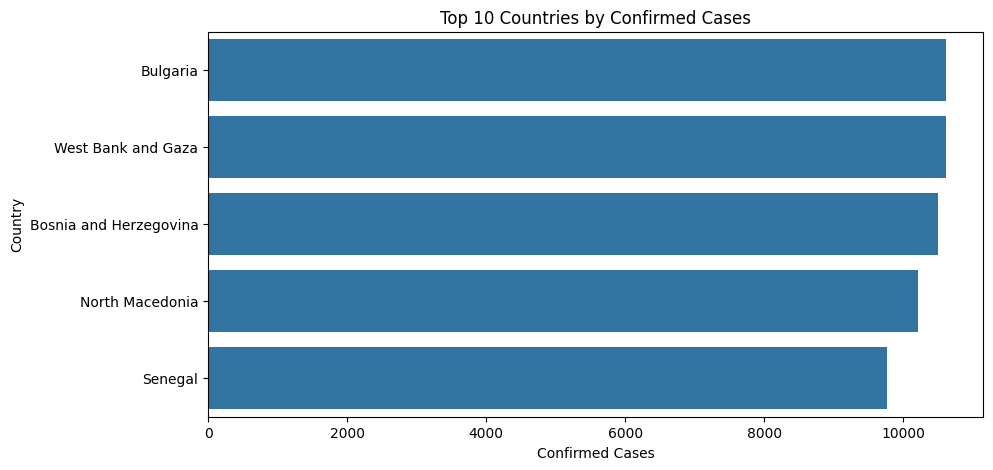

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
top10 = df.sort_values(by="Confirmed", ascending=False).head()

plt.figure(figsize=(10,5))
sns.barplot(data=top10, x="Confirmed", y="Country/Region")

plt.title("Top 10 Countries by Confirmed Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Country")
plt.show()

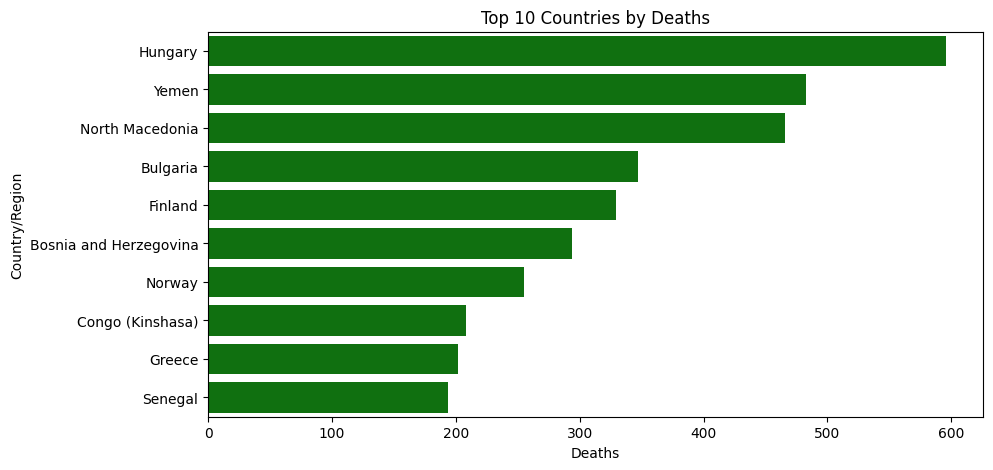

In [ ]:
top10_deaths = df.sort_values(by="Deaths", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top10_deaths, x="Deaths", y="Country/Region",color="green")

plt.title("Top 10 Countries by Deaths")
plt.show()

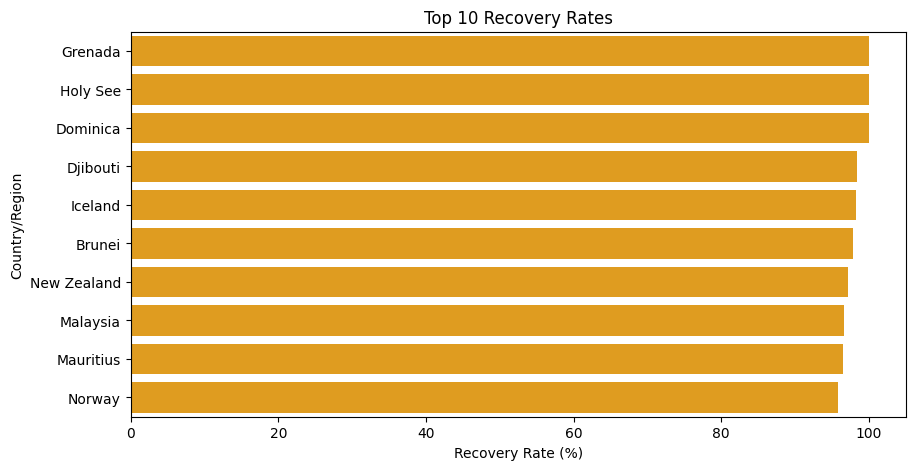

In [ ]:
top_recovery = df.sort_values(by="Recovery_rate", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top_recovery, x="Recovery_rate", y="Country/Region",color="orange")

plt.title("Top 10 Recovery Rates")
plt.xlabel("Recovery Rate (%)")
plt.show()

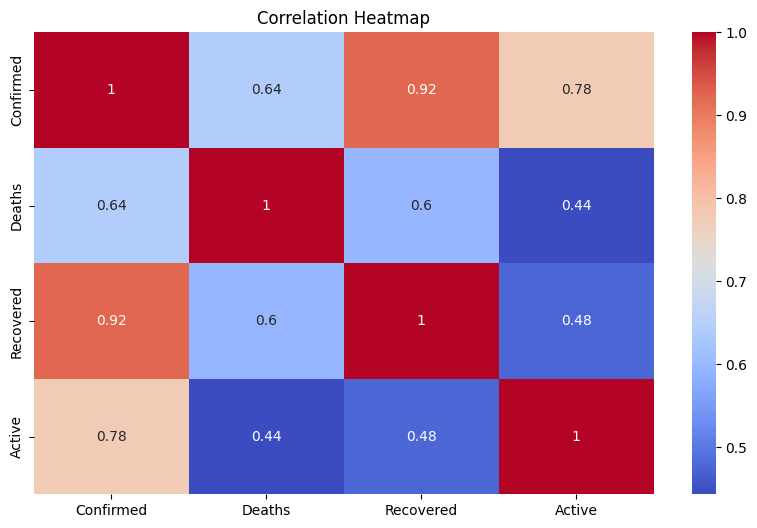

In [ ]:
plt.figure(figsize=(10,6))

corr = df[["Confirmed","Deaths","Recovered","Active"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

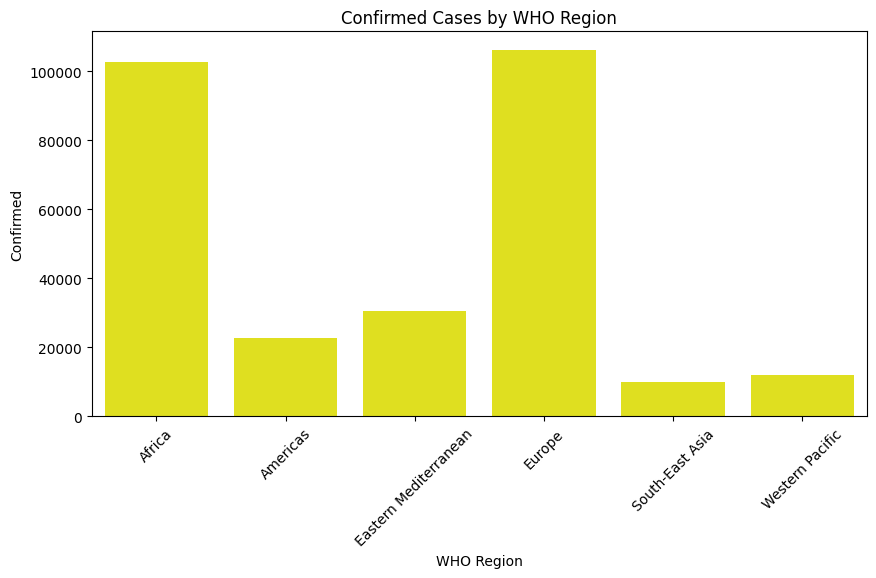

In [ ]:
region_data = df.groupby("WHO Region")["Confirmed"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=region_data, x="WHO Region", y="Confirmed",color="yellow")

plt.title("Confirmed Cases by WHO Region")
plt.xticks(rotation=45)
plt.show()

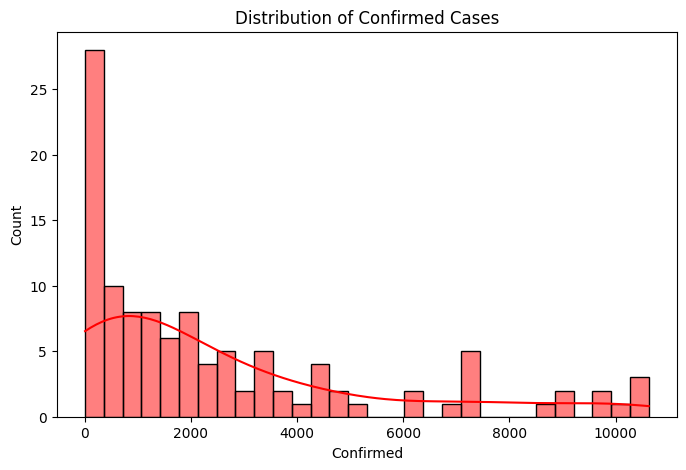

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Confirmed"], bins=30, kde=True,color="red")

plt.title("Distribution of Confirmed Cases")
plt.show()

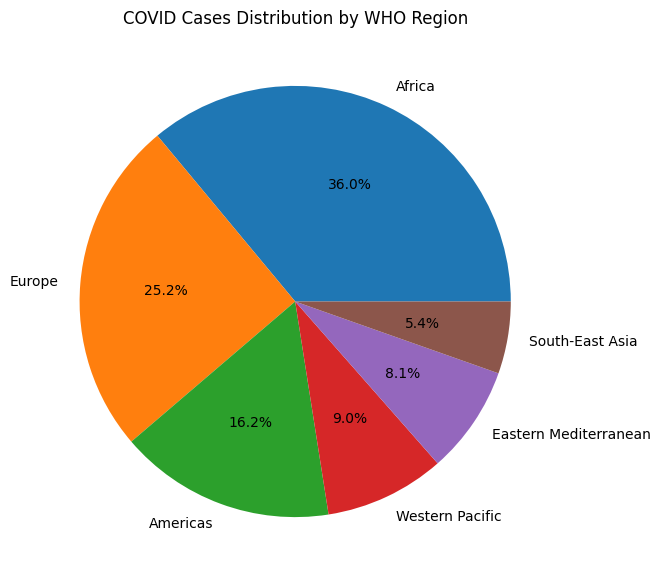

In [ ]:
region_counts = df["WHO Region"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(region_counts, labels=region_counts.index, autopct="%1.1f%%")

plt.title("COVID Cases Distribution by WHO Region")
plt.show()

In [ ]:
# df.to_csv("raw_data.csv", index=False)
df.to_csv("cleaned_data.csv", index=False)
df.to_csv("sorted_data.csv", index=False)
from google.colab import files

# files.download("raw_data.csv")
files.download("cleaned_data.csv")
files.download("sorted_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>